## Cross-validation

Used to estimate how accurately a predictive model will perform in practice.

In [34]:
import sys
print(sys.executable)

# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from physion.analysis.process_NWB import EpisodeData

sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_movement_cond

sys.path.append('../../src')
from sklearn.model_selection import train_test_split
from physion.analysis.read_NWB import Data
from physion.analysis.dataframe import NWB_to_dataframe, extract_stim_keys
from physion.utils import plot_tools as pt

sys.path.append('../../src/physion/analysis')
from cross_validation import TwoFold_train_test_split_basic
from cross_validation import TwoFold_train_test_split

C:\Users\laura.gonzalez\AppData\Local\miniforge3\python.exe


In [35]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
filename = os.path.join(datafolder, '2022_12_15-18-13-25.nwb') #for example
data = Data(filename)

episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name='moving-dots',
                       prestim_duration=0,
                       verbose=False)

HMcond = compute_high_movement_cond(episodes, pupil_threshold=2.9, running_speed_threshold=0.1, metric="locomotion")

df = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

NWB-file reading time: 935.6ms


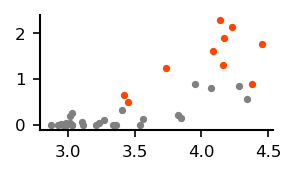

In [36]:
fig = plt.figure(figsize=(2, 1))
plt.plot(episodes.pupil_diameter.mean(axis=1)[~HMcond],
         episodes.running_speed.mean(axis=1)[~HMcond], 'o', color='grey')

plt.plot(episodes.pupil_diameter.mean(axis=1)[HMcond],
         episodes.running_speed.mean(axis=1)[HMcond], 'o', color='orangered')


{'spont_train_sets': [array([ 9609,  9610,  9611, ..., 18433, 18434, 18435]), array([18436, 18437, 18438, ..., 27260, 27261, 27262])], 'spont_test_sets': [array([18436, 18437, 18438, ..., 27260, 27261, 27262]), array([ 9609,  9610,  9611, ..., 18433, 18434, 18435])], 'stim_train_sets': [array([    0,     1,     2, ..., 38605, 38606, 38607]), array([38608, 38609, 38610, ..., 59560, 59561, 59562])], 'stim_test_sets': [array([38608, 38609, 38610, ..., 59560, 59561, 59562]), array([    0,     1,     2, ..., 38605, 38606, 38607])]}
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 16. 17. 18.
 19.]


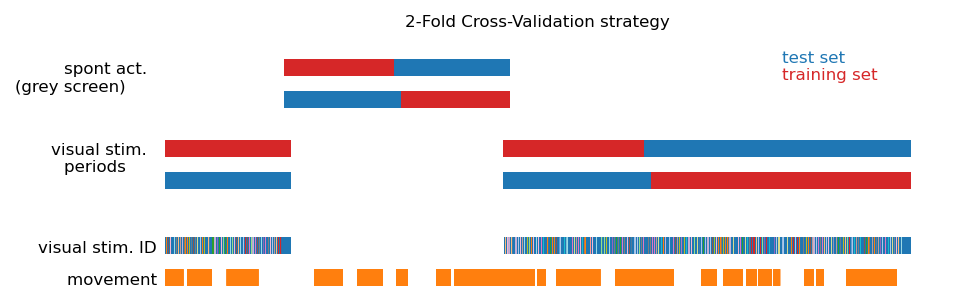

In [37]:
cvIndices = TwoFold_train_test_split_basic(df, spont_act_key='VisStim_grey-10min')
print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

Check how many movement and quiet there is in training and test set 

In [28]:
#2 different state (moving vs quiet)
print(len(np.unique(speed_bool)))

2


In [29]:
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

for i in range(2):
    print(f"{i} CV")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"In the subset {subset}, there is {sum(speed_bool)} moments moving out of {len(speed_bool)}")
        

0 CV
In the subset spont_train_sets, there is 3418 moments moving out of 8827
In the subset spont_test_sets, there is 4169 moments moving out of 8827
In the subset stim_train_sets, there is 9018 moments moving out of 20954
In the subset stim_test_sets, there is 7239 moments moving out of 20955
1 CV
In the subset spont_train_sets, there is 4169 moments moving out of 8827
In the subset spont_test_sets, there is 3418 moments moving out of 8827
In the subset stim_train_sets, there is 7239 moments moving out of 20955
In the subset stim_test_sets, there is 9018 moments moving out of 20954


Check composition of stimuli in training and test sets.

In [30]:
#19 different stimuli
print(np.unique(stim_keys))


['VisStim_Natural-Images-4-repeats--Image-ID_1.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_2.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_3.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_4.0'
 'VisStim_Natural-Images-4-repeats--Image-ID_5.0'
 'VisStim_drifting-gratings--angle_0.0'
 'VisStim_drifting-gratings--angle_180.0'
 'VisStim_drifting-gratings--angle_270.0'
 'VisStim_drifting-gratings--angle_90.0' 'VisStim_grey-10min'
 'VisStim_looming-stim' 'VisStim_moving-dots--speed_60.0'
 'VisStim_moving-dots--speed_90.0' 'VisStim_random-dots--seed_1'
 'VisStim_random-dots--seed_2' 'VisStim_random-dots--seed_3'
 'VisStim_random-dots--seed_4' 'VisStim_static-patch--angle_0.0'
 'VisStim_static-patch--angle_90.0']


In [31]:
cvIndices = TwoFold_train_test_split(filename, data, df, spont_act_key='VisStim_grey-10min')
sets = ['stim_train_sets', 'stim_test_sets']
keys = np.unique(stim_keys)
final = []

for i in range(2):
    print(f'\n CV fold {i}')
    for my_set in sets:
        subset = df[cvIndices[my_set][i][0]:cvIndices[my_set][i][-1]]
        for key in keys:
            stim_cond = (subset[key])
            final.append(np.sum(stim_cond))
            print(f'There is {np.sum(stim_cond)} stimulus {key}')

    #for j in range(len(keys)):
    #    print(f'\nStimulus {keys[j]} :\n {final[j]} in {sets[0]} and {final[j*2]} in {sets[1]}')    


Fold 1 (Spontaneous Activity):
  Training (8827) - Running: 2643, Non-Running: 6184
  Test (8827) - Running: 2643, Non-Running: 6184

Fold 1 (Stimulus-Evoked Activity):
  Training (20954) - Running: 4703, Non-Running: 16251
  Test (20955) - Running: 4704, Non-Running: 16251

Fold 2 (Spontaneous Activity):
  Training (8827) - Running: 2643, Non-Running: 6184
  Test (8827) - Running: 2643, Non-Running: 6184

Fold 2 (Stimulus-Evoked Activity):
  Training (20955) - Running: 4704, Non-Running: 16251
  Test (20954) - Running: 4703, Non-Running: 16251

 CV fold 0
There is 647 stimulus VisStim_Natural-Images-4-repeats--Image-ID_1.0
There is 526 stimulus VisStim_Natural-Images-4-repeats--Image-ID_2.0
There is 588 stimulus VisStim_Natural-Images-4-repeats--Image-ID_3.0
There is 767 stimulus VisStim_Natural-Images-4-repeats--Image-ID_4.0
There is 765 stimulus VisStim_Natural-Images-4-repeats--Image-ID_5.0
There is 353 stimulus VisStim_drifting-gratings--angle_0.0
There is 264 stimulus VisStim_dr


Fold 1
spont_train_sets (8827)
 Running 3418 Non-running 5409
spont_test_sets (8827)
 Running 4169 Non-running 4658
stim_train_sets (20954)
 Running 9018 Non-running 11936
stim_test_sets (20955)
 Running 7239 Non-running 13716

Fold 2
spont_train_sets (8827)
 Running 4169 Non-running 4658
spont_test_sets (8827)
 Running 3418 Non-running 5409
stim_train_sets (20955)
 Running 7239 Non-running 13716
stim_test_sets (20954)
 Running 9018 Non-running 11936


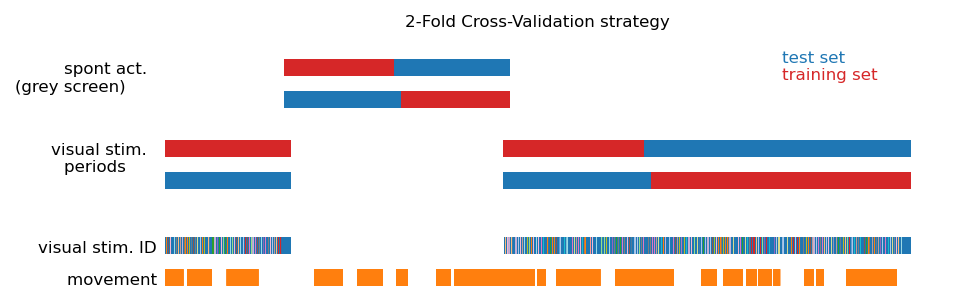

In [32]:
cvIndices = TwoFold_train_test_split_basic( df, spont_act_key='VisStim_grey-10min')
#print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
#print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

# Debugging: Print the number of running/not running instances
for i in range(2):
    print(f"\nFold {i + 1}")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"{subset} ({len(speed_bool)})\n Running {sum(speed_bool)} Non-running {len(speed_bool)- sum(speed_bool) }")



Fold 1 (Spontaneous Activity):
  Training (8827) - Running: 2643, Non-Running: 6184
  Test (8827) - Running: 2643, Non-Running: 6184

Fold 1 (Stimulus-Evoked Activity):
  Training (20954) - Running: 4703, Non-Running: 16251
  Test (20955) - Running: 4704, Non-Running: 16251

Fold 2 (Spontaneous Activity):
  Training (8827) - Running: 2643, Non-Running: 6184
  Test (8827) - Running: 2643, Non-Running: 6184

Fold 2 (Stimulus-Evoked Activity):
  Training (20955) - Running: 4704, Non-Running: 16251
  Test (20954) - Running: 4703, Non-Running: 16251

Fold 1
spont_train_sets (8827)
 Running 3619 Non-running 5208
spont_test_sets (8827)
 Running 3968 Non-running 4859
stim_train_sets (20954)
 Running 9016 Non-running 11938
stim_test_sets (20955)
 Running 7241 Non-running 13714

Fold 2
spont_train_sets (8827)
 Running 3968 Non-running 4859
spont_test_sets (8827)
 Running 3619 Non-running 5208
stim_train_sets (20955)
 Running 7241 Non-running 13714
stim_test_sets (20954)
 Running 9016 Non-runnin

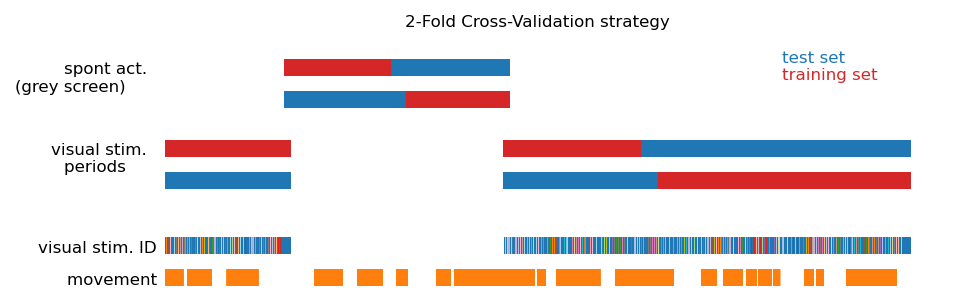

In [33]:
cvIndices = TwoFold_train_test_split(filename, data, df, spont_act_key='VisStim_grey-10min')
#print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=8)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=8)
    ax.scatter(df['time'][test] , ii+0.5+np.zeros(len(df['time'][test])),  c='tab:blue',marker="_", lw=8)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])

for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
        #print(stimID[df[k]])
#print(np.unique(stimID[stim_cond]))
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=8, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=3

#movement
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)  
speed_bool = pd.Series((running_dFoF_sampled >= 0.60).astype(int)) 
ax.scatter(x = df['time'][speed_bool == 1], 
           y = ii + speed_bool[speed_bool == 1] - 0.5, 
           c='tab:orange', 
           marker="_", 
           lw=8, 
           label="Above Threshold")
ax.annotate('movement  ', (0, ii), ha='right')

#final arangements
ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')
ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

running_dFoF_sampled = data.build_running_speed(specific_time_sampling=df['time'].values)

# Debugging: Print the number of running/not running instances
for i in range(2):
    print(f"\nFold {i + 1}")
    for subset in cvIndices.keys():
        speed_bool = pd.Series((running_dFoF_sampled >= 0.10).astype(int))[cvIndices[subset][i]]
        print(f"{subset} ({len(speed_bool)})\n Running {sum(speed_bool)} Non-running {len(speed_bool)- sum(speed_bool) }")
